# Method 1: Multi-Class DR Classification with Class Imbalance Handling

This notebook trains a ResNet-50 model for 5-class DR grading (ICDR scale) on Dataset-02, applying multiple techniques to address the severe class imbalance (~92% Grade 0).

**Class Imbalance Techniques Used:**
1. **Softened Weighted CrossEntropyLoss** - sqrt inverse-frequency class weights (the single imbalance correction; a balanced sampler on top of this over-corrected and collapsed majority-class predictions)
2. **Aggressive Data Augmentation** - rotation, flips, color jitter, random erasing
3. **Learning Rate Scheduling** - CosineAnnealingLR for better convergence
4. **Macro-F1 / balanced-accuracy model selection** - avoids rewarding a trivial majority-class predictor on the 95%-imbalanced set

**Experiment Tracking:** TensorBoard (launch with `tensorboard --logdir=runs`)

**Architecture:** ResNet-50 (ImageNet pretrained) with modified final FC layer for 5-class output.

## 1. Setup & Imports

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    balanced_accuracy_score
)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    # Input shape is fixed at 224x224, so let cuDNN autotune the conv algorithms
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Configuration

In [ ]:
CONFIG = {
    'data_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split'),
    'cache_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split_cache256'),
    'cache_size': 256,
    'img_size': 224,
    'batch_size': 64,
    'num_classes': 5,
    'epochs': 15,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    # 0 = load in the main process. DataLoader worker subprocesses hang under
    # Jupyter on Windows (spawn can't cleanly re-import notebook-defined state),
    # which starves the GPU. The 256px cache makes single-process loading fast
    # enough. To use workers, run this notebook as a .py script instead.
    'num_workers': 0,
    'use_amp': True,
    'seed': 42,
    'model_save_path': 'models/best_method1_multiclass_resnet50.pth',
    'experiment_name': 'DR_Method1_ClassImbalance',
}

DR_LABELS = {
    0: 'No DR',
    1: 'Mild NPDR',
    2: 'Moderate NPDR',
    3: 'Severe NPDR',
    4: 'PDR'
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['seed'])

## 3. Load Data & Analyze Class Imbalance

In [17]:
train_csv = os.path.join(CONFIG['data_dir'], 'train', 'train.csv')
val_csv = os.path.join(CONFIG['data_dir'], 'val', 'val.csv')
test_csv = os.path.join(CONFIG['data_dir'], 'test', 'test.csv')

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

print('\n=== Training Class Distribution ===')
class_counts = train_df['DR_ICDR'].value_counts().sort_index()
for grade, count in class_counts.items():
    print(f'  Grade {grade} ({DR_LABELS[grade]:>15}): {count:>6} ({count/len(train_df)*100:.2f}%)')

print(f'\nImbalance ratio: {class_counts.max()/class_counts.min():.1f}x')

Train: 13015 | Val: 1632 | Test: 1619

=== Training Class Distribution ===
  Grade 0 (          No DR):  12151 (93.36%)
  Grade 1 (      Mild NPDR):    124 (0.95%)
  Grade 2 (  Moderate NPDR):    357 (2.74%)
  Grade 3 (    Severe NPDR):     66 (0.51%)
  Grade 4 (            PDR):    317 (2.44%)

Imbalance ratio: 184.1x


## 4. Compute Class Weights & Sample Weights

In [18]:
# Softened (sqrt) inverse-frequency weights for CrossEntropyLoss.
# Raw inverse frequency produced a 39x-vs-0.2x spread which, stacked on top of
# a balanced sampler, drove the model to never predict the majority class
# (val accuracy collapsed to ~3%). sqrt compresses the spread so minorities are
# still up-weighted without that collapse. We now use weighted loss ONLY and
# drop WeightedRandomSampler to avoid double-correcting the imbalance.
counts_array = np.array([class_counts.get(i, 0) for i in range(CONFIG['num_classes'])])
total_samples = counts_array.sum()

class_weights = np.sqrt(total_samples / (CONFIG['num_classes'] * counts_array))
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('=== Softened (sqrt) Class Weights for Weighted CrossEntropyLoss ===')
for i in range(CONFIG['num_classes']):
    print(f'  Grade {i}: weight = {class_weights[i]:.4f}')
print('\nImbalance handled by weighted loss only (sampler removed).')

=== Softened (sqrt) Class Weights for Weighted CrossEntropyLoss ===
  Grade 0: weight = 0.4628
  Grade 1: weight = 4.5817
  Grade 2: weight = 2.7002
  Grade 3: weight = 6.2801
  Grade 4: weight = 2.8655

Imbalance handled by weighted loss only (sampler removed).


## 5. Data Augmentation & Transforms

Aggressive augmentation helps the model generalize better, especially for under-represented classes.

In [19]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    # RandomErasing operates on tensors, so it must come after ToTensor
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined.')
print(f'  Train: Resize + HFlip + VFlip + Rotation(20) + ColorJitter + Affine + Normalize + RandomErasing')
print(f'  Val/Test: Resize + Normalize')

Transforms defined.
  Train: Resize + HFlip + VFlip + Rotation(20) + ColorJitter + Affine + Normalize + RandomErasing
  Val/Test: Resize + Normalize


## 6. Custom Dataset

In [20]:
class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = int(row['DR_ICDR'])
        return image, label

In [21]:
# Pre-resize the dataset once into a small on-disk cache. Decoding the original
# ~1 MB fundus JPEGs was the training bottleneck: the cache is ~64x smaller and
# decodes an order of magnitude faster. Re-running this cell is a no-op.
from concurrent.futures import ThreadPoolExecutor

CACHE_SIZE = CONFIG['cache_size']


def _resize_one(job):
    src, dst = job
    if os.path.exists(dst):
        return 0
    with Image.open(src) as im:
        # draft() downscales inside the JPEG decoder, far cheaper than
        # decoding at full resolution and resizing afterwards
        im.draft('RGB', (CACHE_SIZE, CACHE_SIZE))
        im = im.convert('RGB').resize((CACHE_SIZE, CACHE_SIZE), Image.BILINEAR)
        im.save(dst, 'JPEG', quality=95)
    return 1


def build_image_cache(split):
    src_dir = os.path.join(CONFIG['data_dir'], split, 'images')
    dst_dir = os.path.join(CONFIG['cache_dir'], split, 'images')
    os.makedirs(dst_dir, exist_ok=True)
    jobs = [(os.path.join(src_dir, n), os.path.join(dst_dir, n))
            for n in os.listdir(src_dir) if n.lower().endswith('.jpg')]
    # PIL releases the GIL during decode/resize, so threads scale here
    with ThreadPoolExecutor(max_workers=8) as ex:
        written = sum(ex.map(_resize_one, jobs, chunksize=32))
    print(f'  {split:>5}: {len(jobs):>6} images ({written} newly written)')
    return dst_dir


print(f'Building {CACHE_SIZE}px image cache (skips files that already exist)...')
train_img_dir = build_image_cache('train')
val_img_dir = build_image_cache('val')
test_img_dir = build_image_cache('test')
print('Cache ready.')

Building 256px image cache (skips files that already exist)...
  train:  13015 images (0 newly written)
    val:   1632 images (0 newly written)
   test:   1619 images (0 newly written)
Cache ready.


In [22]:
# train_img_dir / val_img_dir / test_img_dir are set by the cache cell above
train_dataset = DRDataset(train_df, train_img_dir, transform=train_transforms)
val_dataset = DRDataset(val_df, val_img_dir, transform=val_test_transforms)
test_dataset = DRDataset(test_df, test_img_dir, transform=val_test_transforms)

# JPEG decoding and PIL augmentation are the bottleneck, so keep enough workers
# busy to stay ahead of the GPU. persistent_workers avoids paying the Windows
# process-spawn cost again on every epoch.
loader_kwargs = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=CONFIG['num_workers'] > 0,
    prefetch_factor=4 if CONFIG['num_workers'] > 0 else None,
)

# Weighted loss handles the imbalance now, so use plain shuffling for training
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f'Workers per loader: {CONFIG["num_workers"]}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Workers per loader: 0
Train batches: 407 | Val batches: 51 | Test batches: 51


In [23]:
# No resampling anymore: the training loader reflects the true (imbalanced)
# class distribution, and the weighted loss is what compensates for it.
print('=== Training distribution seen by the model (natural, via shuffle) ===')
natural = train_df['DR_ICDR'].value_counts().sort_index()
for grade, count in natural.items():
    print(f'  Grade {grade} ({DR_LABELS[grade]:>15}): {count:>6} ({count/len(train_df)*100:5.2f}%)')
print('\nMinority classes are up-weighted in the loss instead of oversampled.')

=== Training distribution seen by the model (natural, via shuffle) ===
  Grade 0 (          No DR):  12151 (93.36%)
  Grade 1 (      Mild NPDR):    124 ( 0.95%)
  Grade 2 (  Moderate NPDR):    357 ( 2.74%)
  Grade 3 (    Severe NPDR):     66 ( 0.51%)
  Grade 4 (            PDR):    317 ( 2.44%)

Minority classes are up-weighted in the loss instead of oversampled.


## 7. Model Architecture

In [24]:
def build_resnet50(num_classes, pretrained=True):
    model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )
    return model

model = build_resnet50(CONFIG['num_classes']).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 23,518,277
Trainable parameters: 23,518,277


## 8. Loss Function, Optimizer & Scheduler

In [25]:
# Weighted CrossEntropyLoss for training. Validation uses an UNWEIGHTED loss so
# val loss stays comparable to a standard baseline and isn't inflated by the
# class weights (which is what made the earlier val loss look alarmingly high).
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
val_criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'],
                       weight_decay=CONFIG['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'],
                                                  eta_min=1e-6)

# Mixed precision: uses the Ampere tensor cores and roughly halves activation memory
AMP_ENABLED = CONFIG['use_amp'] and device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

print(f'Loss: Weighted CrossEntropyLoss')
print(f'  Weights: {class_weights_tensor.cpu().numpy().round(4)}')
print(f'Optimizer: Adam (lr={CONFIG["lr"]}, weight_decay={CONFIG["weight_decay"]})')
print(f'Scheduler: CosineAnnealingLR (T_max={CONFIG["epochs"]})')
print(f'Mixed precision (AMP): {AMP_ENABLED}')

Loss: Weighted CrossEntropyLoss
  Weights: [0.4628 4.5817 2.7002 6.2801 2.8655]
Optimizer: Adam (lr=0.0001, weight_decay=1e-05)
Scheduler: CosineAnnealingLR (T_max=15)
Mixed precision (AMP): True


## 9. Training Loop

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    # Accumulate on-device so the loop never blocks on a GPU->CPU sync per batch
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.detach() * images.size(0)
        correct += outputs.detach().argmax(1).eq(labels).sum()
        total += labels.size(0)

    epoch_loss = running_loss.item() / total
    epoch_acc = correct.item() / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
                outputs = model(images)
                loss = criterion(outputs, labels)

            predicted = outputs.argmax(1)
            running_loss += loss.detach() * images.size(0)
            correct += predicted.eq(labels).sum()
            total += labels.size(0)

            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    epoch_loss = running_loss.item() / total
    epoch_acc = correct.item() / total
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, f1_weighted, f1_macro, all_preds, all_labels

In [27]:
# TensorBoard setup
LOG_DIR = 'runs/method1_class_imbalance'
writer = SummaryWriter(log_dir=LOG_DIR)
print(f'TensorBoard log dir: {LOG_DIR}')
print('Launch TensorBoard with: tensorboard --logdir=runs')

# Log hyperparameters as text
hparams_text = '\n'.join([f'{k}: {v}' for k, v in CONFIG.items()])
writer.add_text('Hyperparameters', hparams_text)
writer.add_text('Class_Weights', str(class_weights.round(4).tolist()))
writer.add_text('Techniques', 'Softened WeightedCE (sqrt) + Augmentation + CosineAnnealing')

# Log model graph
dummy_input = torch.randn(1, 3, CONFIG['img_size'], CONFIG['img_size']).to(device)
writer.add_graph(model, dummy_input)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_f1_weighted': [], 'val_f1_macro': [],
    'lr': []
}

best_val_f1_macro = 0.0

for epoch in range(CONFIG['epochs']):
    current_lr = optimizer.param_groups[0]['lr']

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion,
                                            optimizer, device, scaler)
    # Unweighted criterion for validation so val loss is a standard baseline
    val_loss, val_acc, val_f1_w, val_f1_m, val_preds, val_labels = validate(
        model, val_loader, val_criterion, device)
    # Balanced accuracy is the meaningful "accuracy" on a 95%-majority set
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1_weighted'].append(val_f1_w)
    history['val_f1_macro'].append(val_f1_m)
    history['lr'].append(current_lr)

    # Log to TensorBoard
    writer.add_scalars('Loss', {'train': train_loss, 'val': val_loss}, epoch)
    writer.add_scalars('Accuracy', {'train': train_acc, 'val': val_acc}, epoch)
    writer.add_scalar('F1/weighted', val_f1_w, epoch)
    writer.add_scalar('F1/macro', val_f1_m, epoch)
    writer.add_scalar('Balanced_Accuracy/val', val_bal_acc, epoch)
    writer.add_scalar('Learning_Rate', current_lr, epoch)

    # Log per-class F1 to TensorBoard each epoch
    epoch_per_class_f1 = f1_score(val_labels, val_preds, average=None, zero_division=0)
    for i, f in enumerate(epoch_per_class_f1):
        writer.add_scalar(f'F1_PerClass/grade_{i}', f, epoch)

    print(f'Epoch [{epoch+1}/{CONFIG["epochs"]}] '
          f'LR: {current_lr:.6f} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} BalAcc: {val_bal_acc:.4f} | '
          f'F1-W: {val_f1_w:.4f} F1-M: {val_f1_m:.4f}')

    # Select on macro-F1: rewards handling all classes, not just the majority
    if val_f1_m > best_val_f1_macro:
        best_val_f1_macro = val_f1_m
        torch.save(model.state_dict(), CONFIG['model_save_path'])
        print(f'  -> Best model saved (F1-macro: {best_val_f1_macro:.4f})')

writer.flush()
print(f'\nTraining complete. Best validation F1-macro: {best_val_f1_macro:.4f}')

TensorBoard log dir: runs/method1_class_imbalance
Launch TensorBoard with: tensorboard --logdir=runs


Epoch [1/15] LR: 0.000100 | Train Loss: 0.8195 Acc: 0.9078 | Val Loss: 0.3283 Acc: 0.9167 BalAcc: 0.4501 | F1-W: 0.9237 F1-M: 0.3288
  -> Best model saved (F1-macro: 0.3288)


Epoch [2/15] LR: 0.000099 | Train Loss: 0.6877 Acc: 0.9240 | Val Loss: 0.2728 Acc: 0.9436 BalAcc: 0.5988 | F1-W: 0.9442 F1-M: 0.4598
  -> Best model saved (F1-macro: 0.4598)


Epoch [3/15] LR: 0.000096 | Train Loss: 0.6438 Acc: 0.9245 | Val Loss: 0.3019 Acc: 0.9203 BalAcc: 0.7084 | F1-W: 0.9346 F1-M: 0.5302
  -> Best model saved (F1-macro: 0.5302)


Epoch [4/15] LR: 0.000091 | Train Loss: 0.6033 Acc: 0.9268 | Val Loss: 0.2292 Acc: 0.9412 BalAcc: 0.6641 | F1-W: 0.9462 F1-M: 0.5296


...

Epoch [11/15] LR: 0.000026 | Train Loss: 0.4361 Acc: 0.9460 | Val Loss: 0.1577 Acc: 0.9522 BalAcc: 0.6813 | F1-W: 0.9562 F1-M: 0.5923


Epoch [12/15] LR: 0.000017 | Train Loss: 0.4121 Acc: 0.9473 | Val Loss: 0.1544 Acc: 0.9491 BalAcc: 0.7104 | F1-W: 0.9560 F1-M: 0.5963


Epoch [13/15] LR: 0.000010 | Train Loss: 0.3953 Acc: 0.9450 | Val Loss: 0.1310 Acc: 0.9583 BalAcc: 0.6481 | F1-W: 0.9615 F1-M: 0.5928


Epoch [14/15] LR: 0.000005 | Train Loss: 0.3705 Acc: 0.9514 | Val Loss: 0.1367 Acc: 0.9596 BalAcc: 0.6986 | F1-W: 0.9633 F1-M: 0.6499
  -> Best model saved (F1-macro: 0.6499)


Epoch [15/15] LR: 0.000002 | Train Loss: 0.3638 Acc: 0.9513 | Val Loss: 0.1360 Acc: 0.9583 BalAcc: 0.6838 | F1-W: 0.9619 F1-M: 0.6411

Training complete. Best validation F1-macro: 0.6499


## 10. Training History Visualization

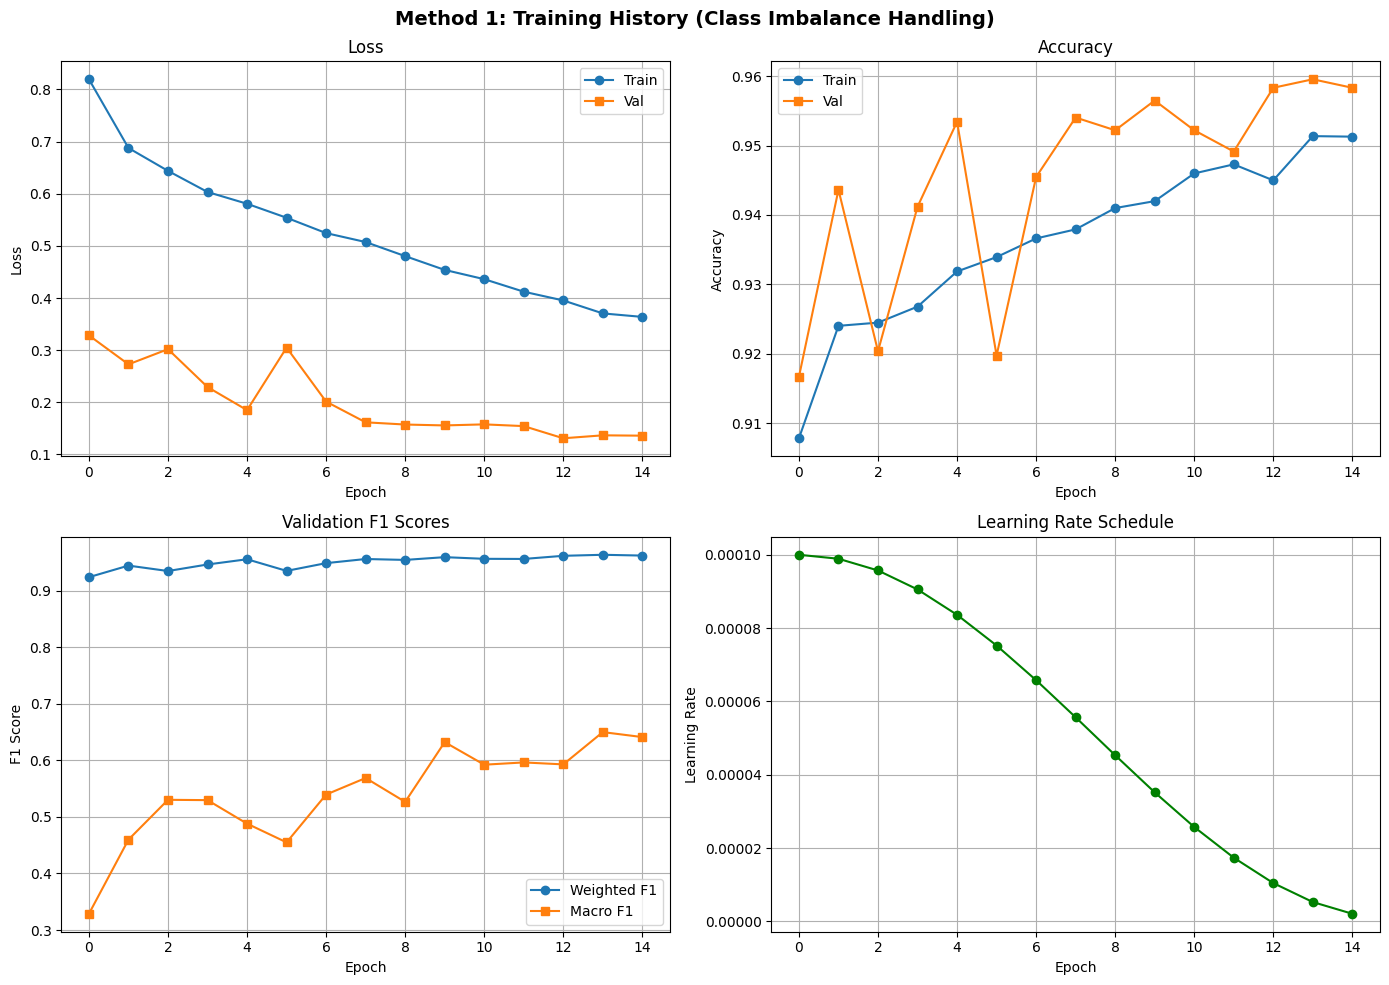

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', marker='o')
axes[0, 1].plot(history['val_acc'], label='Val', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1 Scores
axes[1, 0].plot(history['val_f1_weighted'], label='Weighted F1', marker='o')
axes[1, 0].plot(history['val_f1_macro'], label='Macro F1', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Scores')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Learning Rate
axes[1, 1].plot(history['lr'], marker='o', color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(True)

plt.suptitle('Method 1: Training History (Class Imbalance Handling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/method1_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Test Set Evaluation

In [29]:
# Load best model
model.load_state_dict(torch.load(CONFIG['model_save_path'], map_location=device))

test_loss, test_acc, test_f1_w, test_f1_m, test_preds, test_labels = validate(
    model, test_loader, val_criterion, device)

test_bal_acc = balanced_accuracy_score(test_labels, test_preds)

print('=' * 60)
print('TEST SET RESULTS')
print('=' * 60)
print(f'Test Loss:              {test_loss:.4f}')
print(f'Test Accuracy:          {test_acc:.4f}')
print(f'Test Balanced Accuracy: {test_bal_acc:.4f}')
print(f'Test F1 (weighted):     {test_f1_w:.4f}')
print(f'Test F1 (macro):        {test_f1_m:.4f}')

TEST SET RESULTS
Test Loss:              0.2024
Test Accuracy:          0.9351
Test Balanced Accuracy: 0.6064
Test F1 (weighted):     0.9385
Test F1 (macro):        0.5610


In [30]:
# Classification Report
target_names = [f'Grade {i} ({DR_LABELS[i]})' for i in range(CONFIG['num_classes'])]
print('\n=== Classification Report ===')
print(classification_report(test_labels, test_preds, target_names=target_names,
                            zero_division=0))


=== Classification Report ===
                         precision    recall  f1-score   support

        Grade 0 (No DR)       0.98      0.97      0.97      1488
    Grade 1 (Mild NPDR)       0.25      0.39      0.31        23
Grade 2 (Moderate NPDR)       0.49      0.46      0.47        50
  Grade 3 (Severe NPDR)       0.27      0.50      0.35         6
          Grade 4 (PDR)       0.69      0.71      0.70        52

               accuracy                           0.94      1619
              macro avg       0.54      0.61      0.56      1619
           weighted avg       0.94      0.94      0.94      1619



TensorBoard writer closed. All metrics logged.


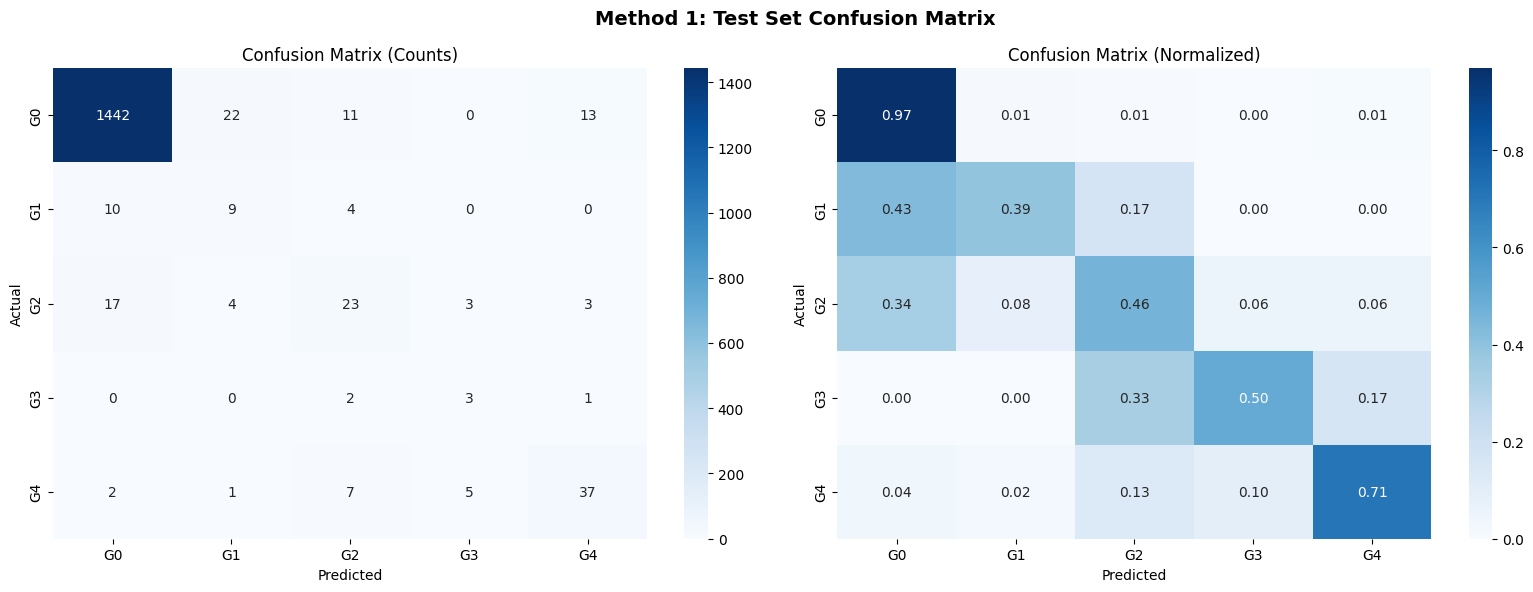

In [35]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'G{i}' for i in range(5)],
            yticklabels=[f'G{i}' for i in range(5)])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'G{i}' for i in range(5)],
            yticklabels=[f'G{i}' for i in range(5)])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle('Method 1: Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/method1_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Log confusion matrix figure to TensorBoard.
# close=False so the figure survives for plt.show() below (default closes it).
writer.add_figure('Test/Confusion_Matrix', fig, close=False)

# Log test metrics to TensorBoard
writer.add_hparams(
    {
        'lr': CONFIG['lr'],
        'batch_size': CONFIG['batch_size'],
        'epochs': CONFIG['epochs'],
        'weight_decay': CONFIG['weight_decay'],
        'img_size': CONFIG['img_size'],
    },
    {
        'hparam/test_accuracy': test_acc,
        'hparam/test_balanced_accuracy': test_bal_acc,
        'hparam/test_f1_weighted': test_f1_w,
        'hparam/test_f1_macro': test_f1_m,
    }
)

writer.close()
print('TensorBoard writer closed. All metrics logged.')
plt.show()

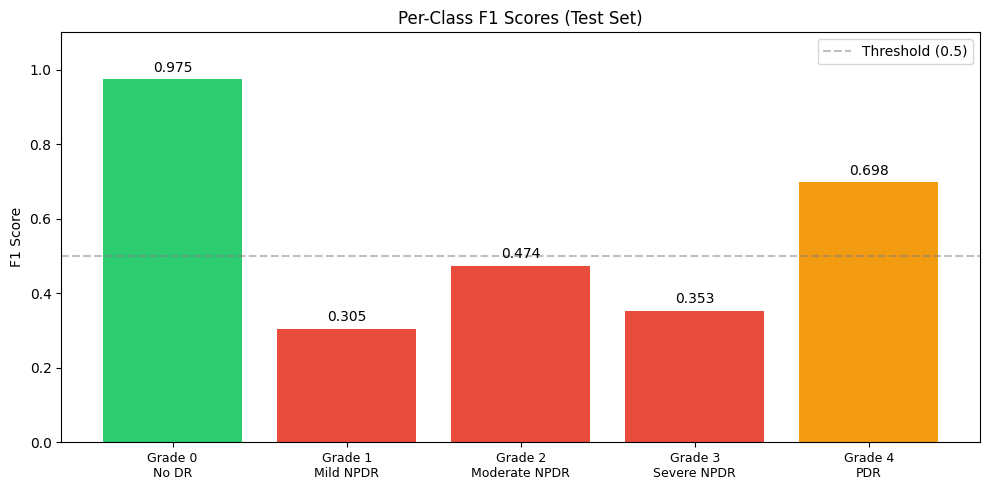

In [32]:
# Per-class F1 scores
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if f < 0.5 else '#f39c12' if f < 0.7 else '#2ecc71' for f in per_class_f1]
bars = ax.bar(range(CONFIG['num_classes']), per_class_f1, color=colors)
ax.set_xticks(range(CONFIG['num_classes']))
ax.set_xticklabels([f'Grade {i}\n{DR_LABELS[i]}' for i in range(CONFIG['num_classes'])], fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores (Test Set)')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold (0.5)')
ax.set_ylim(0, 1.1)
ax.legend()

for bar, f in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{f:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/method1_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary

In [33]:
print('=' * 60)
print('METHOD 1 SUMMARY')
print('=' * 60)
print(f'''
Model: ResNet-50 (ImageNet pretrained)
Task:  5-class DR grading (ICDR scale)

Class Imbalance Techniques Applied:
  1. Softened Weighted CrossEntropyLoss (sqrt inverse-frequency weights)
     - single correction; no sampler, to avoid double-correcting
  2. Aggressive Data Augmentation
     - Random H/V Flip, Rotation(20deg), ColorJitter
     - Random Affine, Random Erasing
  3. CosineAnnealingLR Scheduler
  4. Model selection on macro-F1 (balanced-accuracy reported)

Test Results:
  Accuracy:          {test_acc:.4f}
  Balanced Accuracy: {test_bal_acc:.4f}
  F1 (weighted):     {test_f1_w:.4f}
  F1 (macro):        {test_f1_m:.4f}

Per-Class F1 Scores:''')
for i in range(CONFIG['num_classes']):
    print(f'  Grade {i} ({DR_LABELS[i]:>15}): {per_class_f1[i]:.4f}')

print(f'\nModel saved to: {CONFIG["model_save_path"]}')

METHOD 1 SUMMARY

Model: ResNet-50 (ImageNet pretrained)
Task:  5-class DR grading (ICDR scale)

Class Imbalance Techniques Applied:
  1. Softened Weighted CrossEntropyLoss (sqrt inverse-frequency weights)
     - single correction; no sampler, to avoid double-correcting
  2. Aggressive Data Augmentation
     - Random H/V Flip, Rotation(20deg), ColorJitter
     - Random Affine, Random Erasing
  3. CosineAnnealingLR Scheduler
  4. Model selection on macro-F1 (balanced-accuracy reported)

Test Results:
  Accuracy:          0.9351
  Balanced Accuracy: 0.6064
  F1 (weighted):     0.9385
  F1 (macro):        0.5610

Per-Class F1 Scores:
  Grade 0 (          No DR): 0.9747
  Grade 1 (      Mild NPDR): 0.3051
  Grade 2 (  Moderate NPDR): 0.4742
  Grade 3 (    Severe NPDR): 0.3529
  Grade 4 (            PDR): 0.6981

Model saved to: best_method1_multiclass_resnet50.pth
